In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('/Users/sanskritiroy/Desktop/zomato project/zomato.csv')

In [3]:
print(df.shape)

(51717, 17)


In [4]:
print(df.dtypes)

url                            object
address                        object
name                           object
online_order                   object
book_table                     object
rate                           object
votes                           int64
phone                          object
location                       object
rest_type                      object
dish_liked                     object
cuisines                       object
approx_cost(for two people)    object
reviews_list                   object
menu_item                      object
listed_in(type)                object
listed_in(city)                object
dtype: object


In [5]:
print(df.isnull().sum())

url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64


In [6]:
print(df.head())

                                                 url  \
0  https://www.zomato.com/bangalore/jalsa-banasha...   
1  https://www.zomato.com/bangalore/spice-elephan...   
2  https://www.zomato.com/SanchurroBangalore?cont...   
3  https://www.zomato.com/bangalore/addhuri-udupi...   
4  https://www.zomato.com/bangalore/grand-village...   

                                             address                   name  \
0  942, 21st Main Road, 2nd Stage, Banashankari, ...                  Jalsa   
1  2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...         Spice Elephant   
2  1112, Next to KIMS Medical College, 17th Cross...        San Churro Cafe   
3  1st Floor, Annakuteera, 3rd Stage, Banashankar...  Addhuri Udupi Bhojana   
4  10, 3rd Floor, Lakshmi Associates, Gandhi Baza...          Grand Village   

  online_order book_table   rate  votes                             phone  \
0          Yes        Yes  4.1/5    775    080 42297555\r\n+91 9743772233   
1          Yes         No  4.1/5  

# RATING

In [7]:
df['rate'] = df['rate'].astype(str)
#converting the rating column to string so that funcns like strip and replace can be used


In [8]:
df['rate']=df['rate'].str.replace('/5','').str.strip() # Remove '/5' as a phrase, not just the digit '5'
#Removes /5 and extra space from ratings

In [9]:
df['rate']=pd.to_numeric(df['rate'],errors='coerce')  #replaces invalid values with NaN(the NaN values get ignored if we calculate sum/avg)
#now converting back to number

# COST

In [10]:
df['cost'] = df['approx_cost(for two people)'].astype(str).str.replace(',', '').str.strip()  #removing the commas from the numbers
df['cost'] = pd.to_numeric(df['cost'], errors='coerce')

# VOTES AND RATE

In [11]:
print("Before dropna:", df.shape)

df = df.dropna(subset=['votes', 'rate'])

print("After dropna:", df.shape)

df = df[df['votes'] > 0]

print("After votes filter:", df.shape)

Before dropna: (51717, 18)
After dropna: (41665, 18)
After votes filter: (41646, 18)


# CUISINE BUCKETS

In [12]:
fast_keywords = ['burger', 'pizza', 'fast food', 'sandwich', 'rolls','momos', 'chinese', 'wraps', 'fries', 'hot dog']
healthy_keywords = ['salad', 'healthy', 'juices', 'smoothie','vegan', 'diet', 'organic']
premium_keywords = ['continental', 'italian', 'japanese', 'thai','mediterranean', 'steak', 'sushi', 'french', 'spanish']

def classify_cuisine(c):   #takes one cuisine string
    c = str(c).lower()
    
    fast_score    = sum(k in c for k in fast_keywords)             #by taking the sum checking how many times the fast keyword has come to find out what would be the overall cuisine category)
    healthy_score = sum(k in c for k in healthy_keywords)
    premium_score = sum(k in c for k in premium_keywords)
    # If no keywords match, default to Traditional
    if max(fast_score, healthy_score, premium_score) == 0:
        return 'Traditional'
     # Tie-break
    scores = {'Premium': premium_score, 'Fast': fast_score, 'Healthy': healthy_score}
    return max(scores, key=scores.get)    
    #returns the key for the max value of score
    #if there are multiple keys with the same score,python preserves its insertion order and returns the cuisine that came first in the dictionary
df['cuisine_bucket'] = df['cuisines'].apply(classify_cuisine)  #applying the function to every value in the cuisine column

# CITY TIER

In [13]:
metro_areas = ['Koramangala', 'Indiranagar', 'Whitefield', 'MG Road', 'Brigade Road']
df['city_tier'] = df['location'].apply(                                          #for each location:determine Metro or Tier2
    lambda x: 'Metro' if any(m in str(x) for m in metro_areas) else 'Tier2')   

In [14]:
df.to_csv('/Users/sanskritiroy/Desktop/zomato project/zomato_cleaned.csv', index=False,encoding='utf-8')

In [15]:
#f:Replace anything inside {} with its actual value
print(f"Cleaned dataset: {df.shape[0]} rows, {df.shape[1]} columns")

Cleaned dataset: 41646 rows, 20 columns


In [16]:
print(df[['rate','votes', 'online_order', 'book_table', 'cuisine_bucket', 'city_tier']].head(10))

   rate  votes online_order book_table cuisine_bucket city_tier
0   4.1    775          Yes        Yes           Fast     Tier2
1   4.1    787          Yes         No        Premium     Tier2
2   3.8    918          Yes         No        Premium     Tier2
3   3.7     88           No         No    Traditional     Tier2
4   3.8    166           No         No    Traditional     Tier2
5   3.8    286          Yes         No    Traditional     Tier2
6   3.6      8           No         No           Fast     Tier2
7   4.6   2556          Yes        Yes        Premium     Tier2
8   4.0    324          Yes         No        Premium     Tier2
9   4.2    504          Yes         No        Premium     Tier2


In [21]:
print(df.shape)
print(df[['rate', 'votes', 'online_order', 'cuisine_bucket', 'city_tier']].head(3))

(41646, 20)
   rate  votes online_order cuisine_bucket city_tier
0   4.1    775          Yes           Fast     Tier2
1   4.1    787          Yes        Premium     Tier2
2   3.8    918          Yes        Premium     Tier2


# CHARTS

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

In [23]:
#CHART 1-CONVENIENCE TEST:Do restaurants with online ordering receive more customer engagement?

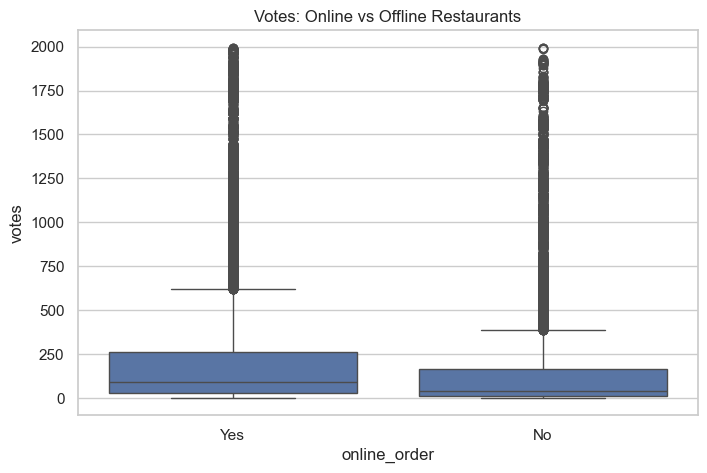

In [42]:
plt.figure(figsize=(8,5))
plot_df = df[df['votes'] <= 2000]  #removing outliers i.e the extremely popular restaurants
sns.boxplot(
    data=plot_df,
    x='online_order',
    y='votes')
plt.title("Votes: Online vs Offline Restaurants")
plt.savefig("charts/chart1_boxplot.png",
            dpi=150,
            bbox_inches="tight")

In [25]:
#CHART 2-CONVENIENCE TEST:Does higher rating lead to more customer engagement?

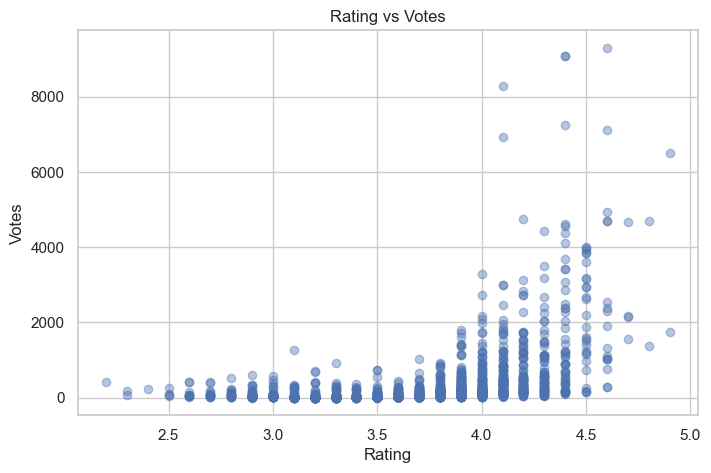

In [43]:
sample = df.sample(2000, random_state=42)  #selecting at random 2000 restaurants from our data
plt.figure(figsize=(8,5))
plt.scatter(
    sample['rate'],
    sample['votes'],
    alpha=0.4)
plt.xlabel("Rating")
plt.ylabel("Votes")
plt.title("Rating vs Votes")
plt.savefig("charts/chart2_scatter.png",
            dpi=150,
            bbox_inches="tight")

In [27]:
#CHART 3-CUSINE ANALYSIS-Which cuisine category attracts the most engagement?

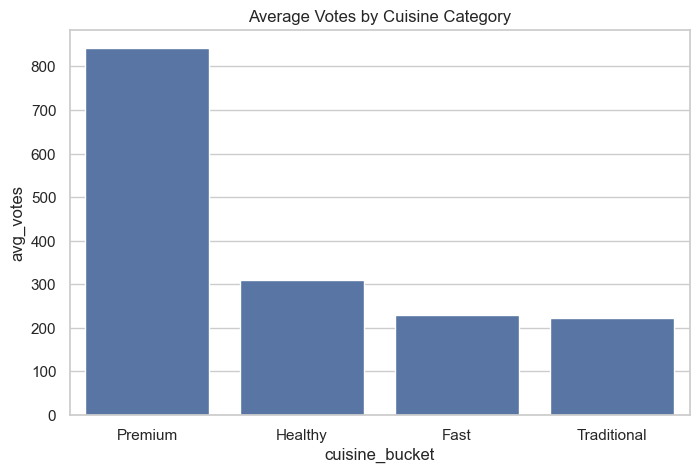

In [44]:
cuisine_summary = (
    df.groupby('cuisine_bucket')
      .agg(
          avg_votes=('votes','mean'),
          avg_rating=('rate','mean')).reset_index()).sort_values('avg_votes', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(
    data=cuisine_summary,
    x='cuisine_bucket',
    y='avg_votes')
plt.title("Average Votes by Cuisine Category")
plt.savefig("charts/chart3_bar.png",
            dpi=150,
            bbox_inches="tight")
plt.show()

In [29]:
#CHART 4-City Tier Analysis:Does convenience matter differently in Metro vs Tier-2 cities?

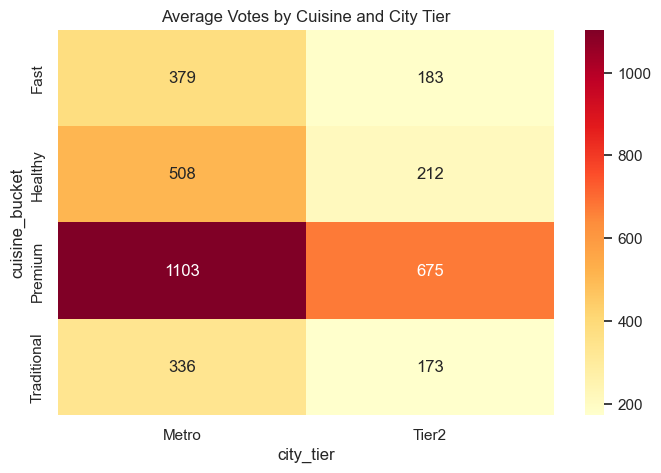

In [45]:
pivot = (
    df.groupby(
        ['cuisine_bucket','city_tier'])['votes'].mean().unstack())

plt.figure(figsize=(8,5))
sns.heatmap(pivot, annot=True,fmt='.0f',cmap="YlOrRd")
plt.title( "Average Votes by Cuisine and City Tier")
plt.savefig("charts/chart4_heatmap.png",
            dpi=150,
            bbox_inches="tight")
plt.show()

# EXPORT DATA FOR EXCEL

In [46]:
online_summary = (
    df.groupby('online_order')
      .agg(avg_votes=('votes', 'mean'),total_restaurants=('name', 'count'),
           avg_rating=('rate', 'mean')  ).round(2).reset_index())

online_summary

,online_order,avg_votes,total_restaurants,avg_rating
0,No,367.61,14455,3.66
1,Yes,343.42,27191,3.72


In [47]:
cuisine_summary = (
    df.groupby('cuisine_bucket')
      .agg(
          avg_votes=('votes', 'mean'),
          avg_rating=('rate', 'mean'),total_restaurants=('name', 'count')).round(2)
      .reset_index())
cuisine_summary

,cuisine_bucket,avg_votes,avg_rating,total_restaurants
0,Fast,229.75,3.60,17251
1,Healthy,309.49,3.76,806
2,Premium,841.60,3.94,8404
3,Traditional,221.66,3.68,15185


In [48]:
tier_summary = (
    df.groupby(['city_tier', 'online_order'])
      .agg(
          avg_votes=('votes', 'mean'),
          total_restaurants=('name', 'count') ).round(2)
      .reset_index())
tier_summary

,city_tier,online_order,avg_votes,total_restaurants
0,Metro,No,675.16,4328
1,Metro,Yes,498.30,7815
2,Tier2,No,236.17,10127
3,Tier2,Yes,280.95,19376


In [51]:
df['rating_band'] = pd.cut(
    df['rate'],
    bins=[0, 3.0, 3.5, 4.0, 4.5, 5.0],
    labels=['Below 3.0','3.0-3.4','3.5-3.9','4.0-4.4','4.5+']
)
#creates a new column called rating band

In [53]:
rating_summary = (
    df.groupby('rating_band', observed=True)
      .agg(avg_votes=('votes', 'mean'),total_restaurants=('name', 'count')).round(2)
    .reset_index())
rating_summary
#with observed=true panda only shows those categories which have some value in them

,rating_band,avg_votes,total_restaurants
0,Below 3.0,100.47,3280
1,3.0-3.4,42.30,11000
2,3.5-3.9,193.18,18152
3,4.0-4.4,964.98,8626
4,4.5+,3445.99,588


In [54]:
path = "dashboard_data.xlsx"

with pd.ExcelWriter(path, engine="openpyxl") as writer: #openpyxl is the library required to open excel files in python


    online_summary.to_excel(
        writer,
        sheet_name="Online vs Offline",
        index=False
    )

    cuisine_summary.to_excel(
        writer,
        sheet_name="Cuisine Buckets",
        index=False
    )

    tier_summary.to_excel(
        writer,
        sheet_name="City Tier",
        index=False
    )

    rating_summary.to_excel(
        writer,
        sheet_name="Rating Bands",
        index=False
    )

    df.to_excel(
        writer,
        sheet_name="Raw Data",
        index=False
    )

print("Excel file created successfully!")

Excel file created successfully!


In [55]:
print(df.groupby('rating_band', observed=True)['votes'].mean().round(2))
print(df['rating_band'].value_counts())

rating_band
Below 3.0     100.47
3.0-3.4        42.30
3.5-3.9       193.18
4.0-4.4       964.98
4.5+         3445.99
Name: votes, dtype: float64
rating_band
3.5-3.9      18152
3.0-3.4      11000
4.0-4.4       8626
Below 3.0     3280
4.5+           588
Name: count, dtype: int64
